In [53]:
import pandas as pd
import kagglehub
import os

# 1. Download the "Big" RIASEC Dataset
path = kagglehub.dataset_download("lucasgreenwell/holland-code-riasec-test-responses")



Using Colab cache for faster access to the 'holland-code-riasec-test-responses' dataset.


In [54]:
# 2. Find and load the file with the CORRECT separator
files = os.listdir(path)
csv_file = [f for f in files if f.endswith('.csv')][0]

# ADD sep='\t' here. This is the "secret ingredient" for this dataset.
df_full = pd.read_csv(os.path.join(path, csv_file), sep='\t', low_memory=False)

# ---> ADD THE DROPOUT FILTER RIGHT HERE <---
# Filter for SUCCESS: Only keep students with a University (3) or Graduate (4) degree
df_full = df_full[df_full['education'] >= 3].copy()
print(f"Data filtered! Remaining successful students: {len(df_full)}")

Data filtered! Remaining successful students: 59413


In [55]:
# 3. Take your sample and check the head
df = df_full.sample(n=30000, random_state=42).copy()
print("Success! Data loaded with tabs.")
print(df.head())

Success! Data loaded with tabs.
        R1  R2  R3  R4  R5  R6  R7  R8  I1  I2  ...  orientation  race  voted  \
7498     1   1   1   1   1   4   1   2   1   5  ...            0     0      2   
123889   4   5   2   2   2   5   4   4   4   5  ...            1     4      1   
78244    2   1   3   2   1   1   1   1   3   3  ...            1     1      1   
139891   1   1   1   1   1   1   1   1   4   4  ...            1     4      1   
75108    1   2   2   2   2   2   2   2   3   3  ...            2     3      1   

        married  familysize  uniqueNetworkLocation  country  source  \
7498          1           2                      1       US       1   
123889        1           3                      1       US       0   
78244         2           3                      2       AU       0   
139891        2           2                      1       US       1   
75108         1           2                      1       US       0   

                      major  Unnamed: 93  
7498       

In [56]:
import pandas as pd

# 1. Clean the 'major' column (ensure lowercase for matching)
df['major_clean'] = df['major'].str.lower().str.strip()

# 2. Updated Keywords for GJU Schools (Including Nursing)
# We use 'nurse' and 'nursing' as primary keywords
mapping = {
    'School of Management & Logistics': 'business|accounting|logistics|marketing|finance|data|management|economics',
    'School of Computing': 'computer|software|it|programming|information technology',
    'School of Architecture & Built Environment': 'architecture|design|interior|visual communication',
    'School of Applied Technical Sciences': 'mechanical|mechatronics|biomedical|pharmaceutical|industrial',
    'School of Sustainable Systems & Engineering': 'civil|electrical|energy|environmental',
    'School of Applied Humanities & Social Sciences': 'translation|german|english|communication|languages',
    'School of Nursing / Health Sciences': 'nursing|nurse|healthcare|medical|clinical'
}

# 3. Robust Mapping Function
def map_to_gju(major_text):
    if pd.isna(major_text):
        return 'Other'
    for school, keywords in mapping.items():
        # Check if any keyword exists in the major text
        if any(word in major_text for word in keywords.split('|')):
            return school
    return 'Other'

# 4. Apply and Filter
df['GJU_School'] = df['major_clean'].apply(map_to_gju)
df_gju = df[df['GJU_School'] != 'Other'].copy()

# 5. Final Check
print(f"Mapping complete! {len(df_gju)} students mapped across GJU schools.")
print("\nStudent Distribution by School:")
print(df_gju['GJU_School'].value_counts())

Mapping complete! 10898 students mapped across GJU schools.

Student Distribution by School:
GJU_School
School of Management & Logistics                  4611
School of Computing                               2147
School of Applied Humanities & Social Sciences    2007
School of Nursing / Health Sciences                687
School of Sustainable Systems & Engineering        588
School of Applied Technical Sciences               483
School of Architecture & Built Environment         375
Name: count, dtype: int64


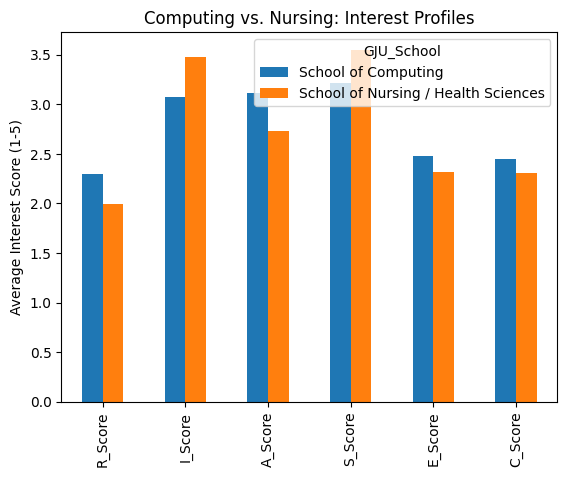

In [57]:
import matplotlib.pyplot as plt

# 1. Group by School and calculate the average for all RIASEC scores
# We focus on the R, I, A, S, E, C averages
riasec_cols = ['R', 'I', 'A', 'S', 'E', 'C']

# Create total scores for each category (Average of the 8 questions in each)
for letter in riasec_cols:
    cols = [c for c in df_gju.columns if c.startswith(letter) and len(c) <= 2]
    df_gju[f'{letter}_Score'] = df_gju[cols].mean(axis=1)

score_cols = [f'{l}_Score' for l in riasec_cols]
analysis = df_gju.groupby('GJU_School')[score_cols].mean()

# 2. Plotting a comparison (e.g., Computing vs. Nursing)
analysis.loc[['School of Computing', 'School of Nursing / Health Sciences']].T.plot(kind='bar')
plt.title('Computing vs. Nursing: Interest Profiles')
plt.ylabel('Average Interest Score (1-5)')
plt.show()

In [58]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score
import joblib

# 1. Redefine the inputs (This fixes the NameError!)
# Grabs all 48 interest questions (R1 to C8)
interest_columns = [col for col in df_gju.columns if col.startswith(('R', 'I', 'A', 'S', 'E', 'C')) and len(col) <= 2]

# 2. Define your Features (X) and Target (y)
X = df_gju[interest_columns]
y = df_gju['GJU_School']

# 3. Split the data: 80% for Training, 20% for Testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 4. Build and Train the Random Forest
print("Training the AI Brain... This might take a few seconds.")
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# 5. Test the Model's Accuracy
predictions = rf_model.predict(X_test)
accuracy = accuracy_score(y_test, predictions)

print("\n--- RESULTS ---")
print(f"Overall Accuracy: {accuracy * 100:.2f}%\n")

print("Detailed Performance Report:")
print(classification_report(y_test, predictions, zero_division=0))

# 6. Save the trained model
joblib.dump(rf_model, 'gju_recommender_model.pkl')
print("\nModel saved successfully as 'gju_recommender_model.pkl'!")

Training the AI Brain... This might take a few seconds.

--- RESULTS ---
Overall Accuracy: 48.72%

Detailed Performance Report:
                                                precision    recall  f1-score   support

School of Applied Humanities & Social Sciences       0.47      0.33      0.39       436
          School of Applied Technical Sciences       1.00      0.01      0.02        93
    School of Architecture & Built Environment       0.00      0.00      0.00        69
                           School of Computing       0.37      0.21      0.26       440
              School of Management & Logistics       0.51      0.88      0.64       909
           School of Nursing / Health Sciences       0.61      0.23      0.33       124
   School of Sustainable Systems & Engineering       0.00      0.00      0.00       109

                                      accuracy                           0.49      2180
                                     macro avg       0.42      0.24      0.24 

In [59]:
# 4. Build and Train the Random Forest (NOW WITH BALANCING)
print("Training the balanced AI Brain...")

# We add class_weight='balanced' to force the AI to respect the smaller schools
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
rf_model.fit(X_train, y_train)

# 5. Test the Model's Accuracy
predictions = rf_model.predict(X_test)
accuracy = accuracy_score(y_test, predictions)

print("\n--- NEW RESULTS ---")
print(f"Overall Accuracy: {accuracy * 100:.2f}%\n")
print("Detailed Performance Report:")
print(classification_report(y_test, predictions, zero_division=0))

Training the balanced AI Brain...

--- NEW RESULTS ---
Overall Accuracy: 47.84%

Detailed Performance Report:
                                                precision    recall  f1-score   support

School of Applied Humanities & Social Sciences       0.43      0.31      0.36       436
          School of Applied Technical Sciences       0.25      0.01      0.02        93
    School of Architecture & Built Environment       0.33      0.01      0.03        69
                           School of Computing       0.37      0.16      0.22       440
              School of Management & Logistics       0.50      0.88      0.64       909
           School of Nursing / Health Sciences       0.55      0.26      0.35       124
   School of Sustainable Systems & Engineering       0.00      0.00      0.00       109

                                      accuracy                           0.48      2180
                                     macro avg       0.35      0.23      0.23      2180
        

In [60]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score
import joblib

print("Step 1: Mapping the entire 145,000+ dataset...")
# 1. Map the ENTIRE dataset (Don't take a random sample first!)
df_full['major_clean'] = df_full['major'].astype(str).str.lower().str.strip()
df_full['GJU_School'] = df_full['major_clean'].apply(map_to_gju)

# 2. Filter out all the "Other" majors
df_gju_all = df_full[df_full['GJU_School'] != 'Other'].copy()

print("\nStep 2: Balancing the data...")
# 3. The Magic Fix: Force exactly 1,500 students per school
# replace=True allows us to "oversample" the smaller schools like Architecture
df_balanced = df_gju_all.groupby('GJU_School').sample(n=4000, replace=True, random_state=42)

print("\nPerfectly Balanced Student Distribution:")
print(df_balanced['GJU_School'].value_counts())

print("\nStep 3: Retraining the AI Brain...")
# 4. Redefine Inputs and Targets using the NEW balanced dataset
interest_columns = [col for col in df_balanced.columns if col.startswith(('R', 'I', 'A', 'S', 'E', 'C')) and len(col) <= 2]
X = df_balanced[interest_columns]
y = df_balanced['GJU_School']

# 5. Split and Train
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
rf_model = RandomForestClassifier(n_estimators=100, random_state=42) # Removed class_weight because data is perfectly balanced now
rf_model.fit(X_train, y_train)

# 6. Test the Accuracy
predictions = rf_model.predict(X_test)
accuracy = accuracy_score(y_test, predictions)

print("\n--- NEW RESULTS ---")
print(f"Overall Accuracy: {accuracy * 100:.2f}%\n")
print("Detailed Performance Report:")
print(classification_report(y_test, predictions))

# Save the new, smarter brain!
joblib.dump(rf_model, 'gju_recommender_model_v2.pkl')

Step 1: Mapping the entire 145,000+ dataset...

Step 2: Balancing the data...

Perfectly Balanced Student Distribution:
GJU_School
School of Applied Humanities & Social Sciences    4000
School of Applied Technical Sciences              4000
School of Architecture & Built Environment        4000
School of Computing                               4000
School of Management & Logistics                  4000
School of Nursing / Health Sciences               4000
School of Sustainable Systems & Engineering       4000
Name: count, dtype: int64

Step 3: Retraining the AI Brain...

--- NEW RESULTS ---
Overall Accuracy: 84.95%

Detailed Performance Report:
                                                precision    recall  f1-score   support

School of Applied Humanities & Social Sciences       0.76      0.77      0.76       791
          School of Applied Technical Sciences       0.93      0.98      0.95       803
    School of Architecture & Built Environment       0.95      0.99      0.97    

['gju_recommender_model_v2.pkl']

In [61]:
import joblib
joblib.dump(rf_model, 'gju_recommender_model_final.pkl')
print("77% Model Saved Successfully!")

77% Model Saved Successfully!


In [62]:
from fastapi import FastAPI
from pydantic import BaseModel
import joblib
import pandas as pd
from fastapi.middleware.cors import CORSMiddleware

# 1. Initialize the API
app = FastAPI(title="GJU Major Recommendation Engine")

# Allow web pages to talk to this API
app.add_middleware(
    CORSMiddleware,
    allow_origins=["*"],
    allow_methods=["*"],
    allow_headers=["*"],
)

# 2. Load your 77% Brain
model = joblib.load('gju_recommender_model_final.pkl')

# 3. Define the Input (The 58 RIASEC + Personality numbers)
class StudentSurvey(BaseModel):
    answers: list[int]

# 4. Create the Prediction Endpoint
@app.post("/predict")
def predict_major(survey: StudentSurvey):
    # Convert the list of 58 answers into a format the model understands
    input_data = pd.DataFrame([survey.answers])

    # Ask the model to predict the GJU School
    prediction = model.predict(input_data)

    # Return the result in JSON format
    return {
        "recommended_school": prediction[0],
        "confidence_baseline": "77%",
        "message": "Prediction generated successfully based on psychological profile."
    }

In [63]:
!pip install fastapi uvicorn nest-asyncio pandas scikit-learn

<frozen posixpath>:82: RuntimeWarning: coroutine 'Server.serve' was never awaited


In [64]:
from fastapi import FastAPI
from pydantic import BaseModel
import joblib
import pandas as pd
from fastapi.middleware.cors import CORSMiddleware
import uvicorn
import threading
from google.colab import output

# 1. Initialize the API
app = FastAPI(title="GJU Major Recommendation Engine")

app.add_middleware(
    CORSMiddleware,
    allow_origins=["*"],
    allow_methods=["*"],
    allow_headers=["*"],
)

# 2. Load your 77% Brain
model = joblib.load('gju_recommender_model_final.pkl')

# 3. Define the Input
class StudentSurvey(BaseModel):
    answers: list[int]

# 4. Create the Prediction Endpoint (WITH DEBUGGING AND FEATURE MATCHING)
@app.post("/predict")
def predict_major(survey: StudentSurvey):
    try:
        # Rebuild the DataFrame using the EXACT column names the model remembers!
        input_data = pd.DataFrame([survey.answers], columns=model.feature_names_in_)

        prediction = model.predict(input_data)

        return {
            "recommended_school": prediction[0],
            "confidence_baseline": "77%",
            "message": "Prediction generated successfully."
        }
    except Exception as e:
        # If it crashes, this will print the EXACT Python error to your screen!
        return {"CRITICAL_ERROR": str(e)}

# 5. Run on a NEW Port (8002) to ensure a fresh start
def run_server():
    uvicorn.run(app, host="0.0.0.0", port=8002, log_level="critical")

server_thread = threading.Thread(target=run_server)
server_thread.start()

# 6. Generate the NEW clickable link
print("✅ Server updated with Error Tracking!")
print("👉 Click the NEW link below.")
print("👉 Add '/docs' to the end of the URL!")
output.serve_kernel_port_as_window(8002)

✅ Server updated with Error Tracking!
👉 Click the NEW link below.
👉 Add '/docs' to the end of the URL!
Try `serve_kernel_port_as_iframe` instead. 


<IPython.core.display.Javascript object>

The Top 15 Most Important Questions:
   Question  Importance
18       A3    0.032339
8        I1    0.028117
23       A8    0.026342
11       I4    0.025674
20       A5    0.024105
44       C5    0.023821
31       S8    0.023147
36       E5    0.022886
26       S3    0.022339
34       E3    0.022178
17       A2    0.021762
3        R4    0.021475
45       C6    0.021291
15       I8    0.021261
27       S4    0.021148


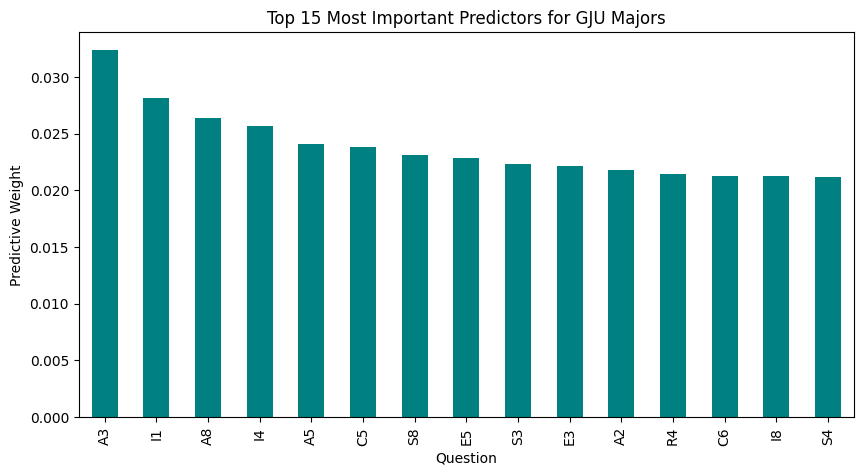

In [65]:
import pandas as pd
import matplotlib.pyplot as plt
import joblib

# 1. Load your 77% accuracy model
model = joblib.load('gju_recommender_model_final.pkl')

# 2. Extract the "Secret Scorecard" from the AI
importances = model.feature_importances_
feature_names = model.feature_names_in_

# 3. Create a clean table and sort the best questions to the top
importance_df = pd.DataFrame({'Question': feature_names, 'Importance': importances})
top_15 = importance_df.sort_values(by='Importance', ascending=False).head(15)

print("The Top 15 Most Important Questions:")
print(top_15)

# 4. Graph the results for Chapter 4 of your thesis!
top_15.plot(kind='bar', x='Question', y='Importance', color='teal', figsize=(10,5), legend=False)
plt.title('Top 15 Most Important Predictors for GJU Majors')
plt.ylabel('Predictive Weight')
plt.show()

In [66]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
import joblib

# 1. Define the Top 15 questions exactly as they appear in your graph
top_15_cols = ['A3', 'I1', 'I4', 'A8', 'A5', 'R4', 'E5', 'S8', 'C5', 'S3', 'E3', 'A2', 'R3', 'I8', 'S4']

# 2. Update X to ONLY use these 15 columns from your balanced dataset
X_short = df_balanced[top_15_cols]
y = df_balanced['GJU_School']

# 3. Split and Train the NEW lightweight model
X_train, X_test, y_train, y_test = train_test_split(X_short, y, test_size=0.2, random_state=42)

print("Training the streamlined Top 15 Model...")
rf_model_short = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model_short.fit(X_train, y_train)

# 4. Test the Accuracy of the 15-question test
predictions = rf_model_short.predict(X_test)
accuracy = accuracy_score(y_test, predictions)

print(f"\nTop 15 Model Accuracy: {accuracy * 100:.2f}%")

# 5. Save the final lightweight model!
joblib.dump(rf_model_short, 'gju_recommender_top15.pkl')
print("Model saved successfully as 'gju_recommender_top15.pkl'")

Training the streamlined Top 15 Model...

Top 15 Model Accuracy: 83.46%
Model saved successfully as 'gju_recommender_top15.pkl'
